In [22]:
import confnotebook

In [23]:
from pathlib import Path

source = Path("../examples/test/full")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 10
[1] 126164
[2] 14964427_Енисейская ТГК-13-БРАЗ
[3] 14976087_АвеларСолар Тех-БРАЗ-1
[4] 15120979_Форвард Энерго-БРАЗ-1
[5] 15235008_ОГК-2-БРАЗ-1
[6] 25
[7] 33
[8] 4
[9] 44
[10] 7-1
[11] АС ВНИИМ Менделеева Д.И. - БРАЗ на 31.12.24
[12] АС ВНИИМ Менделеева Д.И. - РУ на 31.12.24
[13] АС КРЕЗОЛ-САЗ на 31.08.25
[14] АС Охрана Металлург-САЗ на 31.12.25
[15] АС РУ- ВОСЬМОЙ ВЕТРОПАРК
[16] АС Фрейт Линк-БРАЗ на 30.09.25
[17] АСР СДД 2 кв.2024 (подп. к-а)
[18] Акт сверки взаимных расчетов №00000379931 от 30.04.2024
[19] Акт сверки №0000
[20] Акт сверки №MOW00-0087974   от 10.06.2024
[21] Акт сверки №ТРБП-000006 от 10.01.2024
[22] Браз-Юнигрин Пауэр
[23] ЕВР-НКАЗ
[24] Неформализованный_первичный_документ_23_ИИА_03_00342_от_31_03
[25] Неформализованный_первичный_документ_23_ИИА_03_02596_от_31_03
[26] Неформализованный_первичный_документ_23_ИИА_03_03623_от_31_03
[27] Неформализованный_первичный_документ_23_ИИА_06_01794_от_30_06
[28] ПР_АС КРЕЗОЛ-САЗ на 31.08.25
[29] ПР_АС Фрейт Линк-

In [24]:
IDX_FILE = 2

In [25]:
from vision_core.debug_image_observer import DebugImageObserver

file = files[IDX_FILE]
output_dir = f"../examples/output/{file.stem}"

debug_image_observer = DebugImageObserver(output_dir=output_dir)

In [26]:
from vision_core.loader.pdf_loader import PDFLoader
from vision_core.preprocessor.image_orientation import PageOrientationPreprocessor

img = PDFLoader(pdf_bytes=file.read_bytes()).get_page_image(page_num=0, dpi=200)

img, _ = PageOrientationPreprocessor().process(img)

2026-04-28 13:44:55.947 | DEBUG    | vision_core.preprocessor.image_orientation:process:48 - Ориентация страницы: 0° с точностью 0.8415
2026-04-28 13:44:55.957 | DEBUG    | vision_core.preprocessor.image_orientation:process:58 - Вычисленный угол наклона страницы: 0.7029°


In [27]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(20, 30))
# plt.imshow(img)
# plt.title("original image")
# plt.show()

In [28]:
import cv2
import numpy as np

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

# # 3 images visualization
# plt.figure(figsize=(20, 30))
# plt.subplot(1, 3, 1)
# plt.imshow(l, cmap='gray')
# plt.title("lightness")
# plt.subplot(1, 3, 2)
# plt.imshow(a, cmap='gray')
# plt.title("a channel")
# plt.subplot(1, 3, 3)
# plt.imshow(b, cmap='gray')
# plt.title("b channel")
# plt.show()

In [29]:
blur = cv2.GaussianBlur(l, (1, 1), 0)
gamma = 10.0
lut = (np.arange(256) / 255) ** gamma * 255
gamma_img = cv2.LUT(blur, lut.astype(np.uint8))


# plt.figure(figsize=(20, 30))
# plt.imshow(gamma_img, cmap='gray')
# plt.title("gamma corrected lightness channel")
# plt.show()

In [30]:
bin_img = cv2.adaptiveThreshold(gamma_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 50)

# plt.figure(figsize=(20, 30))
# plt.imshow(bin_img, cmap='gray')
# plt.title("binary image")
# plt.show()

In [31]:
bin_img = cv2.dilate(bin_img, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1)), iterations=1)

# plt.figure(figsize=(20, 30))
# plt.imshow(bin_img, cmap='gray')
# plt.title("dilated binary image")
# plt.show()

Median height of horizontal lines: 11


Text(0.5, 1.0, 'line mask')

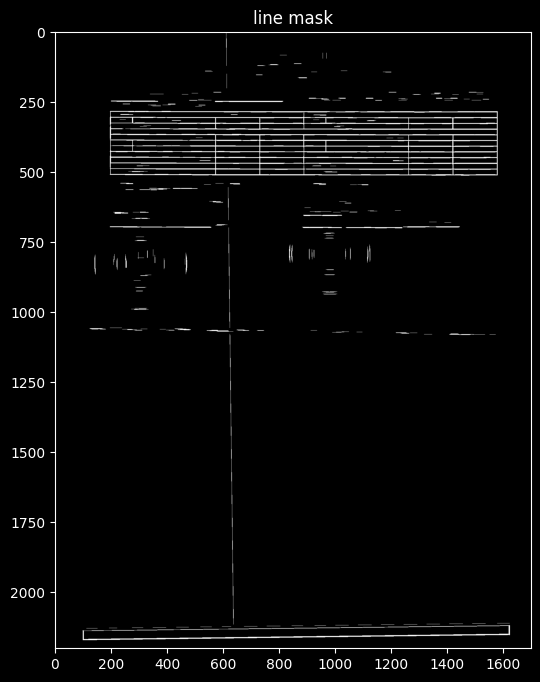

In [ ]:
scale = 150

horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(bin_img.shape[1] / scale), 1))
horizontal_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, horiz_kernel, iterations=2)

# get median height of horizontal lines
horizontal_lines_dilated = cv2.dilate(horizontal_lines, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5)), iterations=2)
contours, _ = cv2.findContours(horizontal_lines_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
heights = [cv2.boundingRect(cnt)[3] for cnt in contours]
median_height = int(np.median(heights))
print(f"Median height of horizontal lines: {median_height}")

vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, median_height))

vertical_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, vertical_kernel, iterations=2)

mask = cv2.bitwise_or(horizontal_lines, vertical_lines)
plt.figure(figsize=(12, 8))
plt.imshow(mask, cmap='gray')
plt.title('line mask')

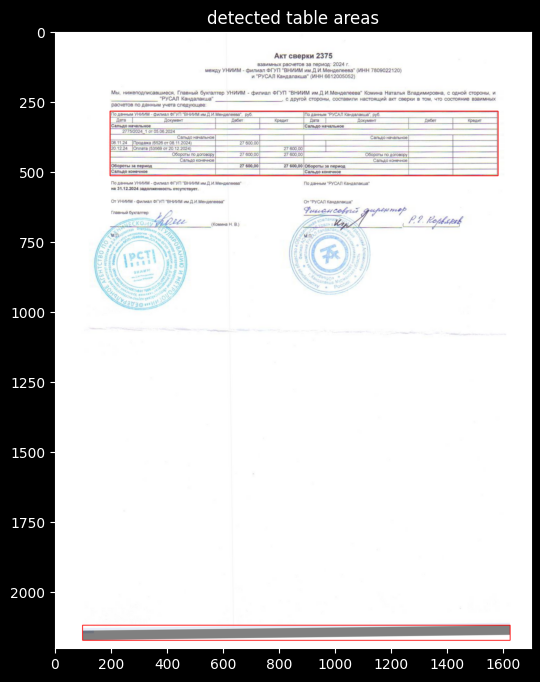

In [33]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_with_boxes = img.copy()

page_width = img.shape[1]

bboxes = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > page_width * 0.5 and h > 20:
        bboxes.append((x, y, w, h))

def is_nested(inner, outer):
    return (inner[0] >= outer[0] and
            inner[1] >= outer[1] and
            inner[0] + inner[2] <= outer[0] + outer[2] and
            inner[1] + inner[3] <= outer[1] + outer[3])

bboxes = [
    a for i, a in enumerate(bboxes)
    if not any(is_nested(a, b) for j, b in enumerate(bboxes) if i != j)
]


for x, y, w, h in bboxes:
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (255, 0, 0), 2)


plt.figure(figsize=(12, 8))
plt.imshow(img_with_boxes)
plt.title('detected table areas')
plt.show()

In [34]:
def merge_close(coords, gap=3):
    coords = np.sort(coords)
    merged = []
    group = [coords[0]]
    for c in coords[1:]:
        if c - group[-1] <= gap:
            group.append(c)
        else:
            merged.append(int(np.mean(group)))
            group = [c]
    merged.append(int(np.mean(group)))
    return np.array(merged)

from collections import defaultdict

def merge_segments(segs, gap=10):
    segs = sorted(segs)
    merged = [list(segs[0])]
    for s, e in segs[1:]:
        if s <= merged[-1][1] + gap:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return merged

def group_and_merge(lines, coord_idx, seg_idx, gap_cluster=3, gap_merge=20):
    coords = merge_close(lines[:, 0, coord_idx], gap=gap_cluster)
    groups = defaultdict(list)
    for seg in lines[:, 0]:
        c = coords[np.argmin(np.abs(coords - seg[coord_idx]))]
        groups[c].append((min(seg[seg_idx], seg[seg_idx+2]), max(seg[seg_idx], seg[seg_idx+2])))
    return {c: merge_segments(segs, gap=gap_merge) for c, segs in groups.items()}

row_height=33, col_width=1521
row_height=20, col_width=158


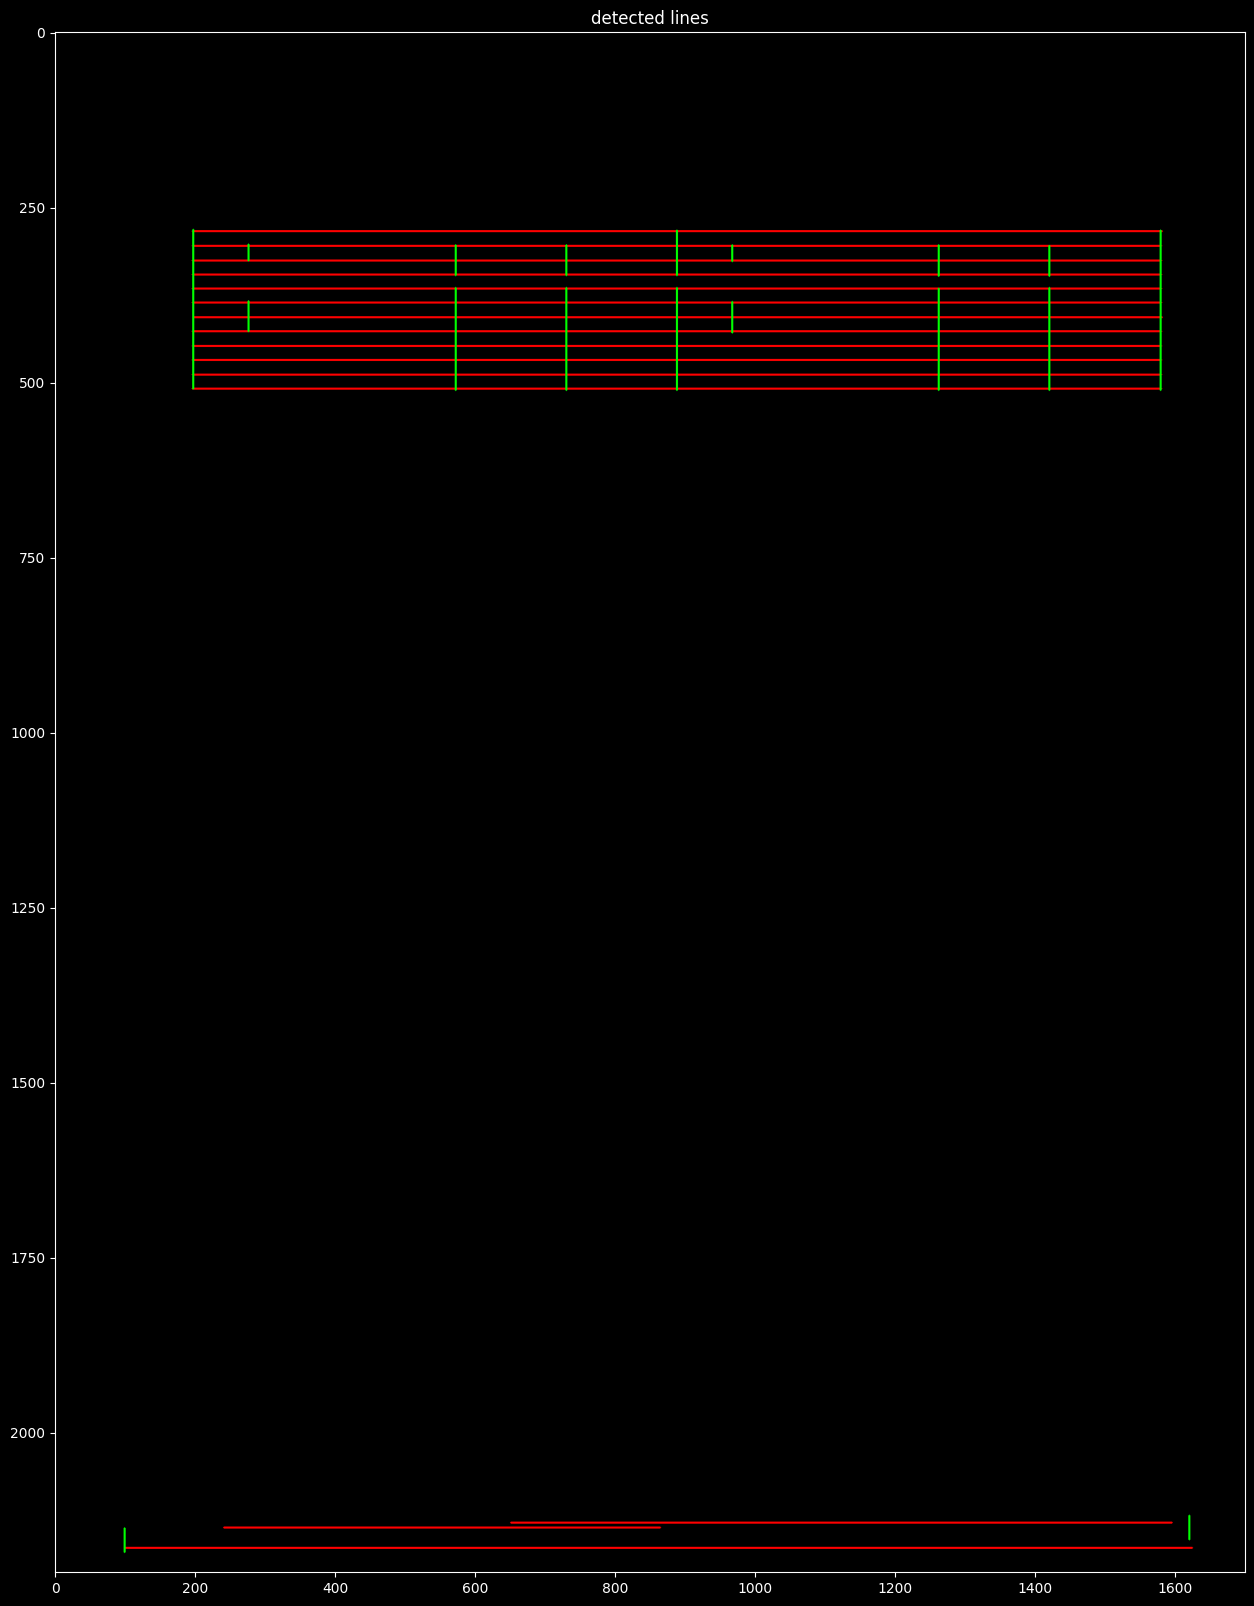

In [35]:
# detected lines
rho = 1  # дистанция разрешающего элемента в пикселях
theta = np.pi / 180  # угловое разрешение в радианах сетки Хафа
threshold = 15  # минимальное количество голосов (пересечений в ячейке сетки Хафа)

max_line_gap = 20  # максимальный разрыв в пикселях между соединяемыми сегментами линий
line_image = np.copy(img) * 0  # создание пустого изображения для рисования линий

roi_vertical = []
roi_horizontal = []
for x, y, w, h in bboxes:
    roi_vertical.append(vertical_lines[y:y+h, x:x+w])
    roi_horizontal.append(horizontal_lines[y:y+h, x:x+w])

for (bx, by, bw, bh), v_roi, h_roi in zip(bboxes, roi_vertical, roi_horizontal, strict=False):
    h_lines = cv2.HoughLinesP(h_roi, rho, theta, threshold, np.array([]),
                              bw // 4, bw // 8)
    if h_lines is not None:
        ys = merge_close(h_lines[:, 0, 1], gap=5)
        row_height = int(np.median(np.diff(ys)))

    v_lines = cv2.HoughLinesP(v_roi, rho, theta, threshold, np.array([]),
                              row_height, row_height * 0.1)
    if v_lines is not None:
        xs = merge_close(v_lines[:, 0, 0], gap=5)
        col_width = int(np.median(np.diff(xs)))

    print(f"row_height={row_height}, col_width={col_width}")

    h_merged = group_and_merge(h_lines, coord_idx=1, seg_idx=0, gap_cluster=3, gap_merge=col_width * 0.8)
    v_merged = group_and_merge(v_lines, coord_idx=0, seg_idx=1, gap_cluster=3, gap_merge=row_height // 2)
   
    for y, segs in h_merged.items():
        for s, e in segs:
            cv2.line(line_image, (bx+s, by+y), (bx+e, by+y), (255, 0, 0), 2)

    for x, segs in v_merged.items():
        for s, e in segs:
            cv2.line(line_image, (bx+x, by+s), (bx+x, by+e), (0, 255, 0), 2)



plt.figure(figsize=(30, 20))
plt.imshow(line_image)
plt.title('detected lines')
plt.show()

rows: 11, cols: 8
ys: [np.int64(2), np.int64(23), np.int64(44), np.int64(64), np.int64(84), np.int64(104), np.int64(125), np.int64(145), np.int64(166), np.int64(186), np.int64(207), np.int64(227)]
xs: [np.int64(1), np.int64(80), np.int64(376), np.int64(534), np.int64(692), np.int64(771), np.int64(1066), np.int64(1224), np.int64(1383)]


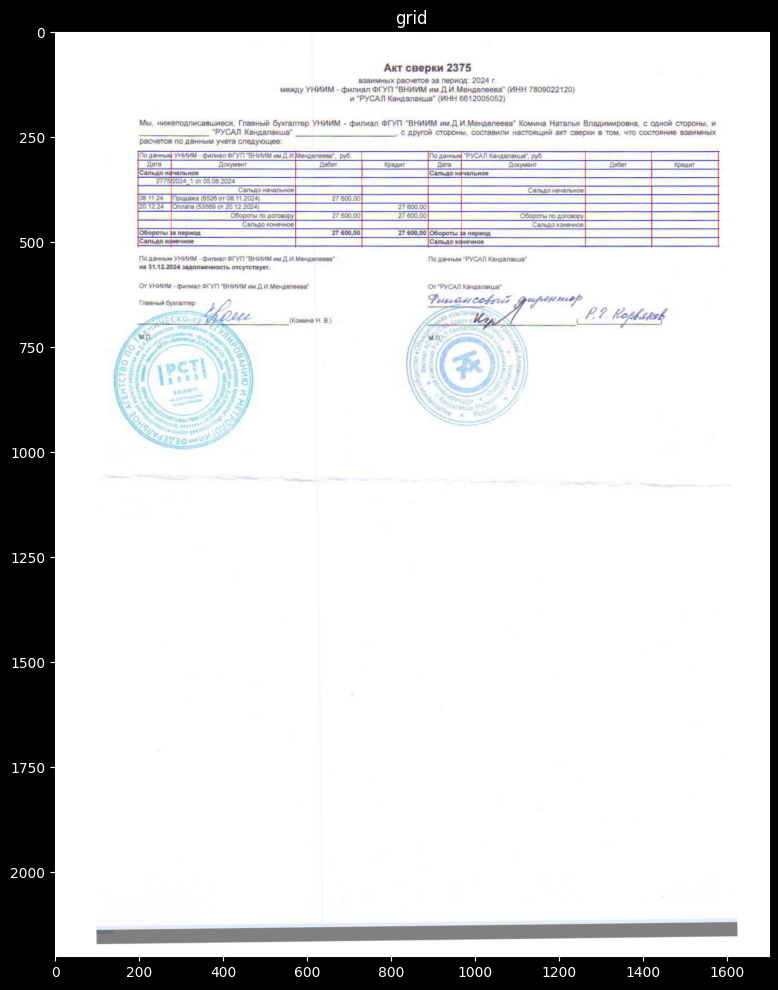

In [36]:
ys = sorted(h_merged.keys())
xs = sorted(v_merged.keys())

# добавляем недостающие границы если линия не найдена у края
if ys[0] > row_height // 4:
    ys = np.concatenate([[0], ys])
if ys[-1] < bh - row_height // 4:
    ys = np.concatenate([ys, [bh]])

if xs[0] > col_width // 4:
    xs = np.concatenate([[0], xs])
if xs[-1] < bw - col_width // 4:
    xs = np.concatenate([xs, [bw]])

print(f"rows: {len(ys)-1}, cols: {len(xs)-1}")
print(f"ys: {ys}")
print(f"xs: {xs}")

# нарисуй только сетку без логики covers
grid_vis = img.copy()
for y in ys:
    cv2.line(grid_vis, (bx, by+y), (bx+bw, by+y), (0, 0, 255), 1)
for x in xs:
    cv2.line(grid_vis, (bx+x, by), (bx+x, by+bh), (255, 0, 0), 1)

plt.figure(figsize=(16, 12))
plt.imshow(grid_vis)
plt.title('grid')
plt.show()


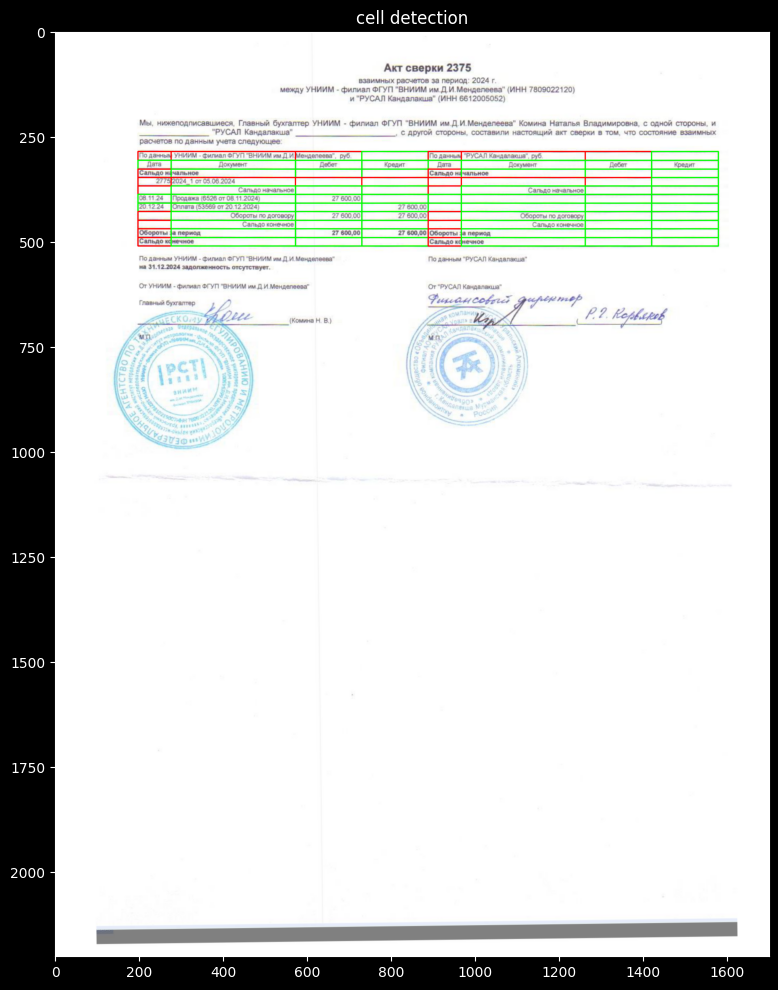

In [37]:
def has_border(segs, start, end):
    """Проверяет, пересекает ли отрезок [start, end] хотя бы один из сегментов в списке segs."""
    mid = (start + end) / 2
    return any(s <= mid <= e for s, e in segs)

vis = img.copy()

for i in range(len(ys) - 1):
    for j in range(len(xs) - 1):
        x0, x1 = xs[j], xs[j+1]
        y0, y1 = ys[i], ys[i+1]

        has_bottom = has_border(h_merged.get(ys[i+1], []), x0, x1)
        has_right  = has_border(v_merged.get(xs[j+1], []), y0, y1)

        color = (0, 255, 0) if (has_bottom and has_right) else (255, 0, 0)
        cv2.rectangle(vis, (bx+x0, by+y0), (bx+x1, by+y1), color, 2)

plt.figure(figsize=(16, 12))
plt.imshow(vis)
plt.title('cell detection')
plt.show()

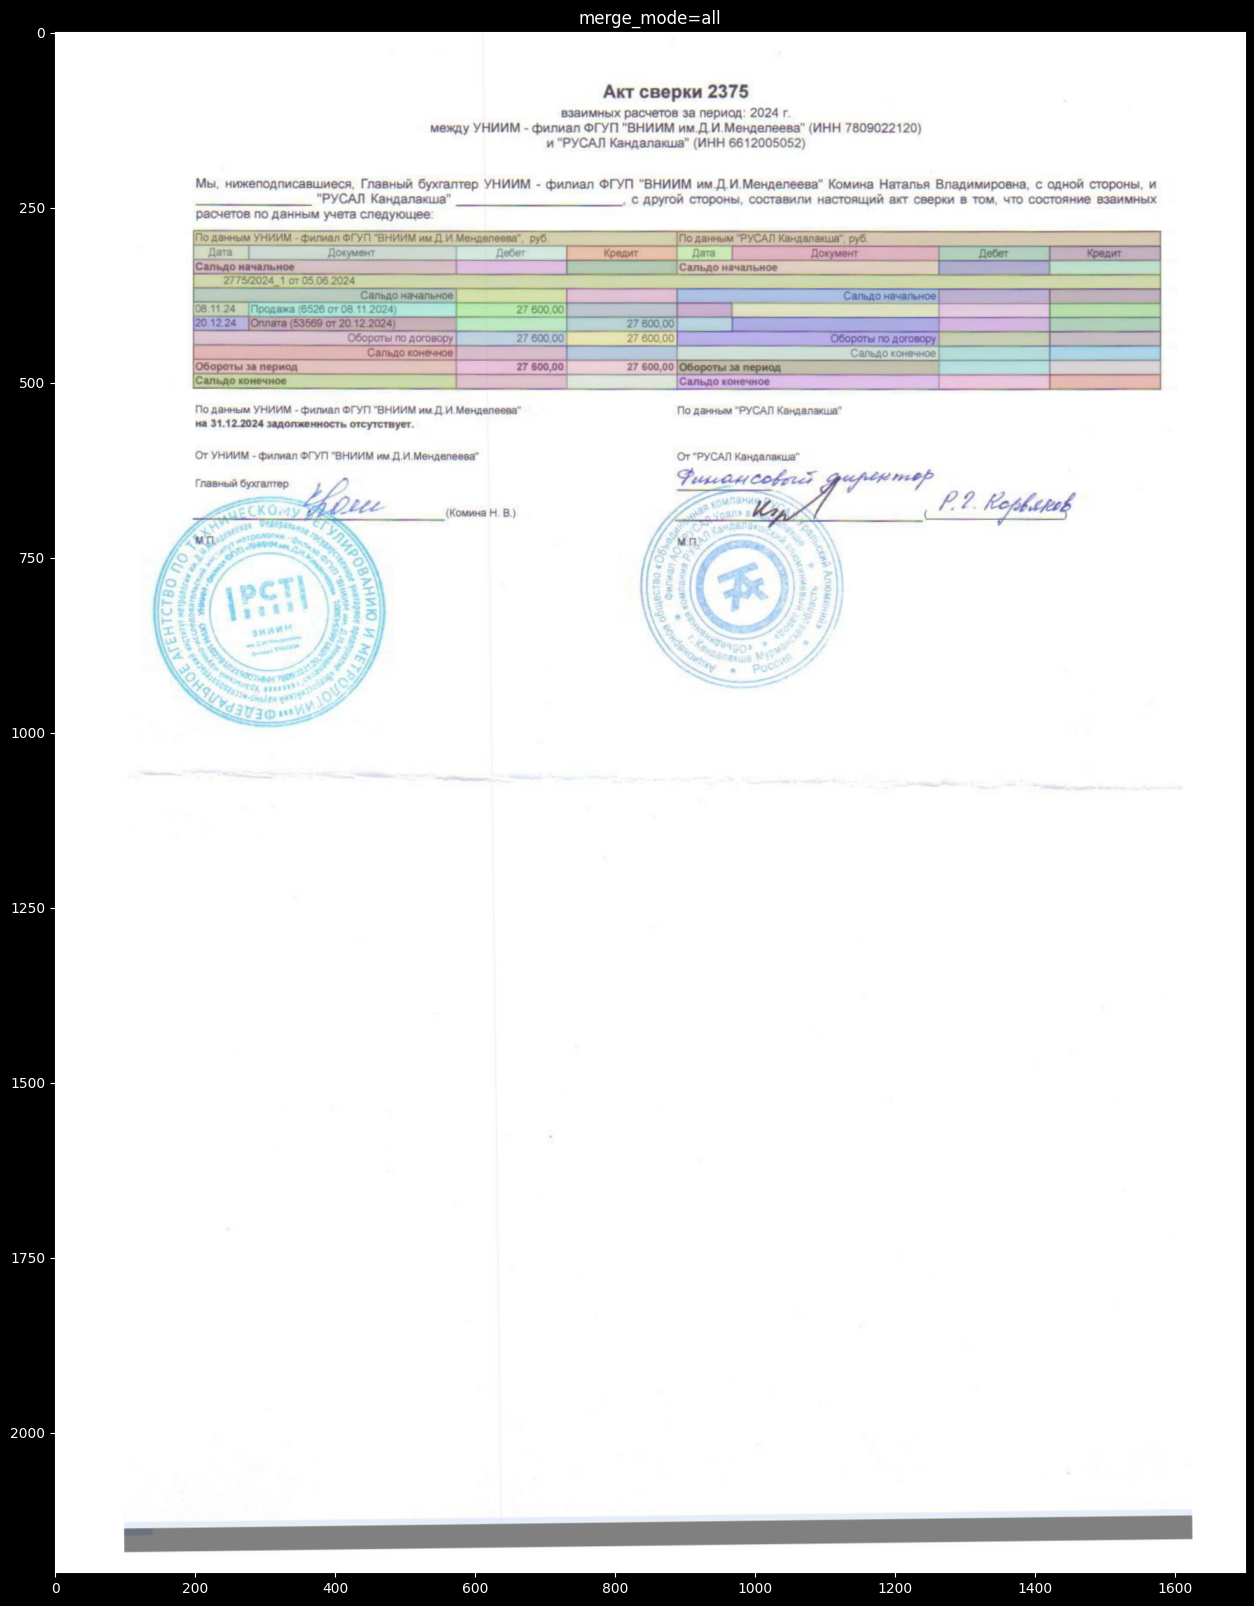

In [40]:
merge_mode = "all"  # "cols", "rows", "all"

n_rows = len(ys) - 1
n_cols = len(xs) - 1

parent = list(range(n_rows * n_cols))

def cell_id(r, c): return r * n_cols + c

def find(node):
    while parent[node] != node:
        parent[node] = parent[parent[node]]
        node = parent[node]
    return node

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

if merge_mode in ("cols", "all"):
    for r in range(n_rows):
        for c in range(n_cols - 1):
            if not has_border(v_merged.get(xs[c+1], []), ys[r], ys[r+1]):
                union(cell_id(r, c), cell_id(r, c+1))

if merge_mode in ("rows", "all"):
    for r in range(n_rows - 1):
        for c in range(n_cols):
            if not has_border(h_merged.get(ys[r+1], []), xs[c], xs[c+1]):
                union(cell_id(r, c), cell_id(r+1, c))

np.random.seed(42)
group_colors = {}
for i in range(n_rows * n_cols):
    g = find(i)
    if g not in group_colors:
        group_colors[g] = tuple(np.random.randint(50, 210, 3).tolist())

overlay = img.copy()
for r in range(n_rows):
    for c in range(n_cols):
        x0, x1 = xs[c], xs[c+1]
        y0, y1 = ys[r], ys[r+1]
        color = group_colors[find(cell_id(r, c))]
        cv2.rectangle(overlay, (bx+x0, by+y0), (bx+x1, by+y1), color, -1)

vis = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

plt.figure(figsize=(30, 20))
plt.imshow(vis)
plt.title(f'merge_mode={merge_mode}')
plt.show()

